In [ ]:
# devtools::install_github("cellgeni/sceasy")

In [1]:
library(scater)
library(scDblFinder)
library(BiocParallel)
library(SeuratObject)
library(Seurat)
source("formating.R")

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [2]:
library(ggplot2)
library(SingleR)
library(dplyr)
library(celldex)
library(RColorBrewer)
library(stringr)
library(DoubletFinder)

RunSeuratQC <- function(input, output, adata_path=NULL, assay='RNA', min_genes=200, max_genes=0, min_UMI_count=0, max_UMI_count=0, percent_mt_max=5, percent_rb_min=0, resolution=0.5, dims=1:10, doublet_rate=0.075, n_hvg=2000, regress_cell_cycle=FALSE) {
    srat <- tryCatch(
        LoadSeurat(input),
        error = function(e) {
            # stop("The file format is not supported.")
            # print(e)
            stop(paste0("The file format is not supported: ", e$message))
        }
    )

    print(str(srat))

    default_assay <- NULL
    assay_names <- NULL
    ddl_assay_names <- TRUE

    if(!is.null(srat)){
        assay_names <- names(srat@assays)
        
        if(length(assay_names)==1){
            assay <- DefaultAssay(srat) # If there is only one assay, then no matter if assay is provided, set assay to default assay
        } else if (assay %in% assay_names){
            DefaultAssay(srat) <- assay # If there is more than one assay, and the user provides assay, then set default assay to assay
        } 
        default_assay <- DefaultAssay(srat)
        print(paste0("Setting default_assay to ", default_assay))

        if(IsNormalized(srat[[default_assay]]$counts, min_genes=min_genes)){
            print("Seurat QC only takes raw counts, not normalized data.")
            stop("Seurat QC only takes raw counts, not normalized data.")
        }

        # Check either the default assay of the Seurat object is "RNA" or the assay is provided by the user.
        if(default_assay==assay){
            # DefaultAssay(srat) <- assay
            if(!paste0("nCount_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nCount_", default_assay)]] <- colSums(x = srat[[default_assay]], slot = "counts")  # nCount of the default assay
            if(!paste0("nFeature_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nFeature_", default_assay)]] <- colSums(x = GetAssayData(object = srat[[default_assay]], slot = "counts") > 0)  # nFeature of the default assay
            
            # Calculate the percentage of mitocondrial per cell and add to the metadata.
            print("Calculating the percentage of mitocondrial per cell and add to the metadata.")
            if(! "percent.mt" %in% names(x = srat[[]])) srat[["percent.mt"]] <- PercentageFeatureSet(srat, pattern = "^MT-")
            # Calculate the proportion gene expression that comes from ribosomal proteins.
            print("Calculating the proportion gene expression that comes from ribosomal proteins.")
            if(! "percent.rb" %in% names(x = srat[[]])) srat[["percent.rb"]] <- PercentageFeatureSet(srat, pattern = "^RP[SL]")

            # Percentage hemoglobin genes - includes all genes starting with HB except HBP.
            print("Calculating the percentage hemoglobin genes - includes all genes starting with HB except HBP.")
            if(! "percent.hb" %in% names(x = srat[[]])) srat[["percent.hb"]] <- PercentageFeatureSet(srat, pattern = "^HB[^(P)]")
            if(! "percent.plat" %in% names(x = srat[[]])) srat[["percent.plat"]] <- PercentageFeatureSet(srat, pattern = "PECAM1|PF4")

            print("Filtering low quality genes/cells.")
            srat <- subset(srat, subset = paste0("nFeature_", default_assay) > min_genes & paste0("nCount_", default_assay) > min_UMI_count & percent.mt < percent_mt_max)
            if(max_genes != 0) srat <- subset(srat, subset = paste0("nFeature_", default_assay) < max_genes)
            if(max_UMI_count != 0) srat <- subset(srat, subset = paste0("nCount_", default_assay) < max_UMI_count)
            if(percent_rb_min != 0)  srat <- subset(srat, subset = percent.rb > percent_rb_min)
            print("Normalizing dataset using logCP10k.")
            srat <- NormalizeData(srat, normalization.method = "LogNormalize", scale.factor = 10000)
            print("Finding variable features.")
            srat <- FindVariableFeatures(srat, selection.method = "vst", nfeatures = n_hvg)
            srat <- subset(srat, features=VariableFeatures(srat)) # Only keep variable features
            print( "Scaling dataset.")
            srat <- ScaleData(srat, features = rownames(srat))

            # PCA
            # srat <- RunPCA(srat, features = VariableFeatures(srat), ndims.print = 6:10, nfeatures.print = 10)
            print("Running PCA.")
            srat <- RunPCA(srat, features=VariableFeatures(srat))

            if(regress_cell_cycle){
                tryCatch({
                    print("Regressing cell cycle.")
                    srat <- RegressCellCycle(srat)
                }, error = function(e) {
                    print(paste0("An error occurred when regressing cell cycle, skipped: ", e$message))
                }) 
            }

            print("Finding neighbors.")
            srat <- FindNeighbors(srat, dims=dims)
            print("Running clustering.")
            srat <- FindClusters(srat, resolution=resolution)
            # TSNE
            print("Running TSNE.")
            srat <- RunTSNE(srat, dims=dims)
            # UMAP
            print("Running UMAP.")
            srat <- RunUMAP(srat, dims=dims)

            # Add the doublet annotation
            if(doublet_rate!=0 & (! "doublet_class" %in% names(x = srat[[]]))){
                tryCatch({
                    ## pK Identification (no ground-truth)
                    set.seed(123)
                    sweep.res.list <- paramSweep(srat, PCs=1:10, sct=FALSE)
                    sweep.stats <- summarizeSweep(sweep.res.list, GT=FALSE)
                    bcmvn <- find.pK(sweep.stats)
                    ## Homotypic Doublet Proportion Estimate
                    nExp_poi <- round(doublet_rate*nrow(srat@meta.data)) ## Assuming 7.5% doublet formation rate - tailor for your dataset
                    # Run DoubletFinder with varying classification stringencies
                    srat <- doubletFinder(srat, PCs = 1:10, pN = 0.25, pK = 0.09, nExp = nExp_poi, reuse.pANN = FALSE, sct = FALSE)
                    # Change the column names of doublet for metadata
                    colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"pANN_")] <- "doublet_score"
                    colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"DF.classifications_")] <- "doublet_class"
                }, error = function(e) {
                    print(e)
                })               
            } 

            # srat <- subset(srat, subset = doublet_class == 'Singlet')
            output <- SaveSeurat(srat, output)
            print("Seurat object is saved successfully.")
            
            if(!is.null(adata_path)){    
                annData <- SeuratToAnndata(srat, out_file=adata_path, assay=assay)
            }
            ddl_assay_names <- FALSE
            rm(srat)
            gc()
        }
    }
    
    list(default_assay=default_assay, assay_names=assay_names, output=output, adata_path=adata_path, ddl_assay_names=ddl_assay_names)
}

RegressCellCycle <- function(srat){
    # Read in the expression matrix The first row is a header row, the first column is rownames
    # exp.mat <- read.table(file = "../tools/qc/nestorawa_forcellcycle_expressionMatrix.txt", header = TRUE,
    #     as.is = TRUE, row.names = 1)

    # A list of cell cycle markers, from Tirosh et al, 2015, is loaded with Seurat.  We can
    # segregate this list into markers of G2/M phase and markers of S phase
    # s.genes <- cc.genes$s.genes
    # g2m.genes <- cc.genes$g2m.genes

    # srat <- CellCycleScoring(srat, s.features = s.genes, g2m.features = g2m.genes, set.ident = TRUE)
    srat <- CellCycleScoring(srat, g2m.features = cc.genes$g2m.genes, s.features = cc.genes$s.genes, set.ident = TRUE)
    srat <- ScaleData(srat, vars.to.regress = c("S.Score", "G2M.Score"), features = rownames(srat))
    
    srat
}


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explain


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘celldex’


The following objects are masked from

In [ ]:
# install.packages("SeuratObject")
# remotes::install_version("Seurat", "4.4.0", repos = c("https://satijalab.r-universe.dev", getOption("repos")))

In [20]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /usr/lib/x86_64-linux-gnu/libmkl_rt.so;  LAPACK version 3.8.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Chicago
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.58.0               DoubletFinder_2.0.6        
 [3] stringr_1.5.1               RColorBrewer_1.1-3         
 [5] celldex_1.18.0              dplyr_1.1.4                
 [7] SingleR_2.10.0              Matrix_1.7-3               
 [9] Signac_1.14.0               patchwork_1.3.1            
[11] SeuratData_0.2.2.9002       Se

In [3]:
path = "../../../oscb/user_storage/Benchmarks/dropletBladder_1755575376199/QC/droplet_Bladder_Seurat.h5ad"
ad <- LoadAnndata(path)
ad

AnnData object with n_obs × n_vars = 2300 × 2000
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id', 'pct_counts_mt', 'pct_counts_rb', 'pct_counts_hb', 'percent.plat', 'RNA_snn_res.0.5', 'seurat_clusters', 'doublet_score', 'doublet_class', 'leiden', 'louvain', 'split_idx'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'highly_variable'
    uns: 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_tsne_3D', 'X_umap', 'X_umap_3D'
    varm: 'PCs'
    layers: 'raw_counts', 'scale.data'
    obsp: 'connectivities', 'distances'

In [13]:
X <- t(ad$X)
class(X)

[1] "matrix" "array"

In [15]:
"matrix" %in% class(X)

[1] TRUE

In [14]:
"dgCMatrix" %in% class(X)

[1] FALSE

In [2]:
# path = "/ps/ai-ready/data/tung/umi.h5Seurat"
# path = "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5ad"
# path = "../../../oscb/user_storage/Benchmarks/droplet-Bladder_1752676773774/droplet_Bladder_seurat_tiss.Robj"
path = "../../../oscb/user_storage/Benchmarks/dropletBladder_1755575376199/QC/droplet_Bladder_Seurat.h5ad"
srat <- LoadSeurat(path)
srat

X -> counts

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from raw_counts_ to rawcounts_”
Adding AnnData layers to Seurat assays

Adding AnnData layers to Seurat assays

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from scvi_normalized_ to scvinormalized_”
Adding AnnData layers to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

Adding AnnData embeddings to Seurat assays

X -> counts



An object of class Seurat 
2000 features across 2300 samples within 1 assay 
Active assay: RNA (2000 features, 0 variable features)
 2 layers present: counts, data

In [4]:
library(dplyr)
library(celldex)
library(RColorBrewer)
library(RhpcBLASctl)
blas_set_num_threads(1)
omp_set_num_threads(1)


clustering <- function(srat, labels, dims=1:10){ # labels: column name of labels in srat@meta.data
    # srat <- CleanSeurat(srat)
    srat <- FindVariableFeatures(srat, selection.method = "vst")
    srat <- ScaleData(srat, features = rownames(srat))

    # PCA
    # srat <- RunPCA(srat, features = VariableFeatures(srat), ndims.print = 6:10, nfeatures.print = 10)
    srat <- RunPCA(srat, features = VariableFeatures(srat))

    srat <- FindNeighbors(srat, dims=dims)
    srat <- FindClusters(srat, resolution = 0.5)
    srat

    # TSNE
    srat <- RunTSNE(srat, dims=dims)
    # UMAP
    srat <- RunUMAP(srat, dims=dims)

    umap <- Embeddings(object = srat, reduction = "umap")
    output <- paste0(tools::file_path_sans_ext(path), ".rds")
    saveRDS(object = srat, file = output)

    list(labels=as.list(srat@meta.data[labels]), labels_pred=as.list(srat@meta.data["seurat_clusters"]), umap=umap)
}


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union


The following object is masked from ‘package:generics’:

    explain


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:
result <- clustering(srat, 'cell_ontology_class')

Centering and scaling data matrix

PC_ 1 
Positive:  Lgals1, Vim, Serpinh1, Sparc, Serping1, Col1a2, Col3a1, Bgn, Col1a1, Dcn 
	   Plac9, Mgp, Rarres2, Col6a1, Htra1, Rcn3, Tuba1a, Nbl1, Plac8, Pcolce 
	   Col6a2, Mxra8, Fstl1, Gadd45g, Lsp1, Cd302, Nupr1, Ppic, Cygb, Id3 
Negative:  Foxq1, Mal, Ly6d, Wfdc2, Fxyd3, Krt18, Gsta4, Spint2, 2200002D01Rik, Krt7 
	   Aqp3, Perp, Sfn, 1110032A04Rik, Krt19, Krt8, Gsto1, Sprr1a, Cldn4, Gstm1 
	   Upk1a, Ezr, Igfbp2, Lmo1, Sdc1, Cldn7, Mgst3, Ivl, Cdh1, Ctse 
PC_ 2 
Positive:  Tyrobp, Ctss, H2-Aa, H2-Eb1, Cd52, Laptm5, Cd74, Fcer1g, Cd83, Ly86 
	   H2-DMa, H2-Ab1, Sfpi1, Plek, Coro1a, Cd53, Srgn, Pld4, Plbd1, Lyz2 
	   Alox5ap, Lyz1, H2-DMb1, Bcl2a1d, Bcl2a1b, Il1b, Ms4a6c, Clec12a, AF251705, Lilrb4 
Negative:  S100a6, Serpinh1, Col3a1, Dcn, Col1a2, Col1a1, Mgp, Gsn, Col6a1, Sparc 
	   Htra1, Rcn3, Serping1, Pcolce, Bgn, Ppap2b, Dkk3, Ecm1, Mxra8, Fbln5 
	   Mmp2, Nbl1, Ppic, Rarres2, Col5a2, Dnajb1, Col6a2, Col6a3, Id3, Fstl1 
PC_ 3 
Positive: 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2300
Number of edges: 68011

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8877
Number of communities: 10
Elapsed time: 0 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
00:02:04 UMAP embedding parameters a = 0.9922 b = 1.112

00:02:04 Read 2300 rows and found 10 numeric columns

00:02:04 Using Annoy for neighbor search, n_neighbors = 30

00:02:04 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:02:05 Writing NN index file to temp file /tmp/RtmpD1LI0n/file18a4913811b

00:02:05 Searching Annoy index using 1 thread, search_k = 3000

00:02:06 Annoy recall = 100%

00:02:07 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

In [3]:
srat <- CleanSeurat(srat)
# srat <- FindVariableFeatures(srat, selection.method = "vst")
# srat <- ScaleData(srat, features = rownames(srat))

In [ ]:
RunSeuratQC(path, "../../../oscb/user_storage/Benchmarks/droplet-Bladder_1752676773774/droplet_Bladder_seurat_tiss.h5seurat")

Updating from v2.X to v3.X

Warning message:
“Not validating Assay objects”
Warning message:
“Not validating Assay objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘tsne’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in tsne

Setting tsne DimReduc to global

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Validatin

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:7620996] 3 10 22 24 27 50 53 54 98 132 ...
  .. .. .. .. .. .. ..@ p       : int [1:2501] 0 2853 7047 10394 14245 18054 21662 26009 27969 30205 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 23341 2500
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:7620996] 1 1 1 1 1 21 1 1 1 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:2500, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. ..$ : c

Normalizing layer: counts



[1] "Finding variable features."


Finding variable features for layer counts



In [5]:
robj <- get(load(path))
robj

An old seurat object
 23341 genes across 2500 samples

In [6]:
srat_v3 <- UpdateSeuratObject(robj)
srat_v3

Updating from v2.X to v3.X

Warning message:
“Not validating Assay objects”
Warning message:
“Not validating Assay objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Warning message:
“Not validating Seurat objects”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘tsne’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in tsne

Setting tsne DimReduc to global

Validating object structure for Assay ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘tsne’

Obj

An object of class Seurat 
23341 features across 2500 samples within 1 assay 
Active assay: RNA (23341 features, 1559 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, tsne

In [4]:
srat <- LoadSeurat(path)
srat

Updating from v2.X to v3.X

Warning message:
“Not validating Assay objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘tsne’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in tsne

Setting tsne DimReduc to global

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Validating object structure for Assay ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘tsne’

Object representation is consistent with the most current Seurat version



An object of class Seurat 
23341 features across 2500 samples within 1 assay 
Active assay: RNA (23341 features, 0 variable features)
 2 layers present: counts, data

In [5]:
annData <- SeuratToAnndata(srat, out_file="../../../oscb/user_storage/Benchmarks/droplet-Bladder_1752676773774/droplet_Bladder_seurat_tiss.h5ad", assay='RNA')

In [5]:
annData

AnnData object with n_obs × n_vars = 2500 × 23341
    obs: 'orig.ident', 'n_counts', 'n_genes', 'channel', 'tissue', 'subtissue', 'mouse.sex', 'mouse.id', 'percent.ercc', 'percent.ribo', 'free_annotation', 'cell_ontology_class', 'res.0.4', 'previous_free_annotation', 'previous_cell_ontology_class', 'cluster.ids', 'cell_ontology_id'
    var: 'name'

In [6]:
annData$X

  [[ suppressing 32 column names ‘Xkr4’, ‘Rp1’, ‘Sox17’ ... ]]



2500 x 23341 sparse Matrix of class "dgCMatrix"
                                                                               
10X_P4_3_AAAGTAGAGATGCCAG . .  . 1 .  . . . . . 1 . . . . . . . . . . . 1 . 1 .
10X_P4_3_AACCGCGTCCAACCAA . .  . . 2  3 . . . . 2 . . . . 2 . . 1 . . . . . 1 .
10X_P4_3_AACTCCCGTCGGGTCT . .  . . 1  1 . 2 . . 1 . . . . . . . . . . . . . 1 .
10X_P4_3_AACTCTTAGTTGCAGG . .  . . 2  . . 1 . . . . . . . . . . . . . . . . . .
10X_P4_3_AACTCTTTCATAACCG . .  . . .  1 . 1 . . . . . 1 . 1 . . . . . . . . . .
10X_P4_3_AAGACCTAGATCCGAG . .  . 2 3  1 . . . . . . . . . . . . . . . . . . . .
10X_P4_3_AAGACCTAGGTGGGTT . .  . . 1  1 . 1 . . 1 . . . . 2 . . . . . . 1 . 3 .
10X_P4_3_AAGGAGCGTGCAACTT . .  . . .  . . . . . . . . . . . . . . . . . . . . .
10X_P4_3_AAGTCTGAGATAGTCA . .  . . .  1 . 1 . . . . . 1 . 1 . . . . 1 . . . 1 .
10X_P4_3_ACAGCTATCATACGGT . .  . . 1  . . . . . 1 . . 2 . . . . . . . . 1 . . .
10X_P4_3_ACATACGCAGCTCCGA . .  . . .  . . . . . . . . . . . . . . . . . 

In [11]:
srat[['RNA']]$meta.features

Warning message:
“Layer ‘meta.features’ is empty”


0 x 0 sparse Matrix of class "dgCMatrix"
<0 x 0 matrix>

In [31]:
names(srat@meta.data)

[1] "orig.ident"                   "nCount_RNA"                  
 [3] "nFeature_RNA"                 "channel"                     
 [5] "tissue"                       "subtissue"                   
 [7] "mouse.sex"                    "mouse.id"                    
 [9] "percent.ercc"                 "percent.ribo"                
[11] "free_annotation"              "cell_ontology_class"         
[13] "res.0.4"                      "previous_free_annotation"    
[15] "previous_cell_ontology_class" "cluster.ids"                 
[17] "cell_ontology_id"             "percent.mt"                  
[19] "percent.rb"                   "percent.hb"                  
[21] "percent.plat"                 "RNA_snn_res.0.5"             
[23] "seurat_clusters"

In [6]:
adata_path=NULL
assay='RNA'
min_genes=200
max_genes=0
min_UMI_count=0
max_UMI_count=0
percent_mt_max=5
percent_rb_min=0
resolution=0.5
dims=1:10
doublet_rate=0.075
n_hvg=2000
regress_cell_cycle=FALSE

In [7]:
assay_names <- names(srat@assays)
        
if(length(assay_names)==1){
    assay <- DefaultAssay(srat) # If there is only one assay, then no matter if assay is provided, set assay to default assay
} else if (assay %in% assay_names){
    DefaultAssay(srat) <- assay # If there is more than one assay, and the user provides assay, then set default assay to assay
} 
default_assay <- DefaultAssay(srat)
print(paste0("Setting default_assay to ", default_assay))

[1] "Setting default_assay to RNA"


In [8]:
if(IsNormalized(srat[[default_assay]]$counts, min_genes=min_genes)){
    print("Seurat QC only takes raw counts, not normalized data.")
    stop("Seurat QC only takes raw counts, not normalized data.")
}

In [9]:
# DefaultAssay(srat) <- assay
if(!paste0("nCount_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nCount_", default_assay)]] <- colSums(x = srat[[default_assay]], slot = "counts")  # nCount of the default assay
if(!paste0("nFeature_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nFeature_", default_assay)]] <- colSums(x = GetAssayData(object = srat[[default_assay]], slot = "counts") > 0)  # nFeature of the default assay

# Calculate the percentage of mitocondrial per cell and add to the metadata.
print("Calculating the percentage of mitocondrial per cell and add to the metadata.")
if(! "percent.mt" %in% names(x = srat[[]])) srat[["percent.mt"]] <- PercentageFeatureSet(srat, pattern = "^MT-")
# Calculate the proportion gene expression that comes from ribosomal proteins.
print("Calculating the proportion gene expression that comes from ribosomal proteins.")
if(! "percent.rb" %in% names(x = srat[[]])) srat[["percent.rb"]] <- PercentageFeatureSet(srat, pattern = "^RP[SL]")

# Percentage hemoglobin genes - includes all genes starting with HB except HBP.
print("Calculating the percentage hemoglobin genes - includes all genes starting with HB except HBP.")
if(! "percent.hb" %in% names(x = srat[[]])) srat[["percent.hb"]] <- PercentageFeatureSet(srat, pattern = "^HB[^(P)]")
if(! "percent.plat" %in% names(x = srat[[]])) srat[["percent.plat"]] <- PercentageFeatureSet(srat, pattern = "PECAM1|PF4")

print("Filtering low quality genes/cells.")
srat <- subset(srat, subset = paste0("nFeature_", default_assay) > min_genes & paste0("nCount_", default_assay) > min_UMI_count & percent.mt < percent_mt_max)
if(max_genes != 0) srat <- subset(srat, subset = paste0("nFeature_", default_assay) < max_genes)
if(max_UMI_count != 0) srat <- subset(srat, subset = paste0("nCount_", default_assay) < max_UMI_count)
if(percent_rb_min != 0)  srat <- subset(srat, subset = percent.rb > percent_rb_min)
print("Normalizing dataset using logCP10k.")
srat <- NormalizeData(srat, normalization.method = "LogNormalize", scale.factor = 10000)
print("Finding variable features.")
srat <- FindVariableFeatures(srat, selection.method = "vst", nfeatures = n_hvg)
srat <- subset(srat, features=VariableFeatures(srat)) # Only keep variable features
print( "Scaling dataset.")
srat <- ScaleData(srat, features = rownames(srat))

[1] "Calculating the percentage of mitocondrial per cell and add to the metadata."
[1] "Calculating the proportion gene expression that comes from ribosomal proteins."
[1] "Calculating the percentage hemoglobin genes - includes all genes starting with HB except HBP."
[1] "Filtering low quality genes/cells."
[1] "Normalizing dataset using logCP10k."
[1] "Finding variable features."
[1] "Scaling dataset."


Centering and scaling data matrix



In [9]:
VariableFeatures(srat)

[1] "Rgs20"         "Ppp1r42"       "Eya1"          "Trpa1"        
   [5] "Rdh10"         "Tceb1"         "Il17f"         "Gsta3"        
   [9] "Gm4956"        "Col9a1"        "Gm13363"       "Dst"          
  [13] "Cox5b"         "Mrpl30"        "Eif5b"         "Pdcl3"        
  [17] "Gm3646"        "Il18rap"       "2900092D14Rik" "4832428D23Rik"
  [21] "Col3a1"        "Col5a2"        "Obfc2a"        "Hspd1"        
  [25] "Hspe1"         "Bzw1"          "Clk1"          "Ndufb3"       
  [29] "Als2cr12"      "Nop58"         "4930487H11Rik" "Eef1b2"       
  [33] "Snora41"       "Idh1"          "Ikzf2"         "Fn1"          
  [37] "4933417E11Rik" "Tmem169"       "March4"        "Igfbp2"       
  [41] "Arpc2"         "Prkag3"        "Ihh"           "Tuba4a"       
  [45] "Acsl3"         "Scg2"          "Gm7609"        "2810459M11Rik"
  [49] "Htr2b"         "Ncl"           "Prss56"        "Trpm8"        
  [53] "Col6a3"        "Lrrfip1"       "Espnl"         "Klhl30"       
  [57] "Myeov2"        "Hdlbp"         "Gal3st2"       "Pdcd1"        
  [61] "LOC626049"     "Serpinb5"      "Dbi"           "Actr3"        
  [65] "Slc35f5"       "Cd55"          "Il10"          "Ctse"         
  [69] "Nucks1"        "Snrpe"         "Zc3h11a"       "Prelp"        
  [73] "Btg2"          "Adipor1"       "Elf3"          "Csrp1"        
  [77] "Gm16880"       "Rgs2"          "Ptgs2"         "1700025G04Rik"
  [81] "Arpc5"         "E330020D12Rik" "1700012A16Rik" "C230024C17"   
  [85] "Rgsl1"         "Glul"          "Ier5"          "1700057K13Rik"
  [89] "Pappa2"        "Ankrd45"       "Prdx6"         "Fasl"         
  [93] "AI848100"      "2810442N19Rik" "7420461P10Rik" "Prrc2c"       
  [97] "Gm16548"       "F5"            "Brp44"         "Creg1"        
 [101] "Dusp27"        "Mgst3"         "Rxrg"          "Pbx1"         
 [105] "Rgs5"          "Fcer1g"        "Pfdn2"         "Pvrl4"        
 [109] "F11r"          "Tagln2"        "Olfr433"       "1700016C15Rik"
 [113] "Hnrnpu"        "Lefty2"        "Srp9"          "1700047M11Rik"
 [117] "Capn8"         "Hhipl2"        "Mosc1"         "Cenpf"        
 [121] "Atf3"          "Rd3"           "Kcnh1"         "Irf6"         
 [125] "Hsd11b1"       "Camk1g"        "Cd34"          "Cr2"          
 [129] "Akap12"        "Rmnd1"         "Ipcef1"        "Ulbp1"        
 [133] "Gm6150"        "Gm20125"       "3110003A17Rik" "Hebp2"        
 [137] "Perp"          "Tnfaip3"       "Il20ra"        "Myb"          
 [141] "Gm5420"        "Sgk1"          "H60b"          "Tcf21"        
 [145] "Tmem200a"      "Samd3"         "Col10a1"       "Hs3st5"       
 [149] "Marcks"        "Cd24a"         "Popdc3"        "Fam162b"      
 [153] "BB019430"      "Ddit4"         "Psap"          "Sgpl1"        
 [157] "Hkdc1"         "Srgn"          "Reep3"         "Ank3"         
 [161] "Cisd1"         "Ipmk"          "Mif"           "Chchd10"      
 [165] "1700027D21Rik" "Col6a2"        "Col6a1"        "Gm17769"      
 [169] "Pttg1ip"       "Dnmt3l"        "Cstb"          "C2cd4c"       
 [173] "Ptbp1"         "C030046I01Rik" "Grin3b"        "Midn"         
 [177] "Uqcr11"        "Mknk2"         "Tmprss9"       "Timm13"       
 [181] "Gadd45b"       "Zbtb7a"        "Mrpl54"        "Mfsd12"       
 [185] "Aes"           "Txnrd1"        "Timp3"         "Hsp90b1"      
 [189] "Stab2"         "Sycp3"         "Slc17a8"       "Slc25a3"      
 [193] "Snrpf"         "Gm15915"       "Metap2"        "Ndufa12"      
 [197] "Tmcc3"         "Btg1"          "Dcn"           "Lum"          
 [201] "Atp2b1"        "Dusp6"         "Gm20110"       "Myf5"         
 [205] "Otogl"         "Csrp2"         "Phlda1"        "Atxn7l3b"     
 [209] "Tspan8"        "4933416C03Rik" "D630029K05Rik" "Cct2"         
 [213] "Lyz2"          "Lyz1"          "4933411E08Rik" "Ifng"         
 [217] "Grip1"         "Llph"          "D930020B18Rik" "Avpr1a"       
 [221] "Cyp27b1"       "Ndufa4l2"      "Lrp1"          "Myo1a"        
 [225] "Naca"          "Ptg

In [10]:
# srat[['RNA']]$data@x[is.na(srat[['RNA']]$data@x)] <- 0

In [17]:
# srat[['RNA']]$data@x[is.na(srat[['RNA']]$data@x)] <- 0
# srat <- ScaleData(srat, features = rownames(srat))
# srat <- RunPCA(srat, features=VariableFeatures(srat))

In [16]:
library(irlba)
set.seed(1000)
mat <- matrix(data = rnorm(n = 3000*2000), nrow = 3000, ncol = 2000)
test <- irlba(mat, nv = 50)

In [14]:
packageVersion("irlba")

[1] ‘2.3.5.1’

In [15]:
library(RhpcBLASctl)
blas_set_num_threads(1)
omp_set_num_threads(1)

In [18]:
# PCA
# srat <- RunPCA(srat, features = VariableFeatures(srat), ndims.print = 6:10, nfeatures.print = 10)
print("Running PCA.")
# srat <- RunPCA(srat, npcs = 30, features=VariableFeatures(srat))
srat <- RunPCA(srat, features=VariableFeatures(srat))

[1] "Running PCA."


PC_ 1 
Positive:  Cds1, Cxadr, Gpa33, Lad1, Fer1l4, Baiap2l1, Snx31, Tmprss13, Prss22, Rab15 
	   Serpinb5, Ocln, Ckmt1, Ank3, Fa2h, Pvrl4, Sdcbp2, Ikzf2, Degs2, Trp63 
	   Ppargc1a, Sytl1, Pdk4, Zfp750, Alcam, Syngr1, Fam84a, Rnf144b, Plekhg6, Ccbl1 
Negative:  Mustn1, Hsd11b1, Calcrl, AW112010, Ly6c1, Il11ra1, Fhl1, Scarf2, Colec12, Wfdc1 
	   Mdk, Htra3, Thsd4, Cxcl12, 3632451O06Rik, Kazald1, Igfbp4, Ddah2, Asz1, Fermt2 
	   Ndufa4l2, Sfrp2, Fbn1, Col14a1, Lbp, Enpp2, Cd200, Tmem119, Fblim1, Aldh1a2 
PC_ 2 
Positive:  Htra3, Hsd11b1, Fhl1, Colec12, Scarf2, Kazald1, Lbp, Asz1, Wfdc1, Mdk 
	   Calcrl, 3632451O06Rik, Fbn1, Loxl1, Mustn1, Ddah2, Thsd4, Sfrp2, Col8a1, Notum 
	   Enpp2, Grem2, Cpz, Cxcl12, Inmt, Kcnk2, Avpr1a, Scara5, Ndufa4l2, Ccdc80 
Negative:  Tyrobp, Ctss, Fcer1g, Cd83, Lyz2, Lyz1, Plek, Plbd1, Alox5ap, Srgn 
	   Bcl2a1d, Il1b, Cd14, Ptpn18, Slfn2, Hcls1, C1qb, C1qa, C1qc, Lrrc33 
	   Cxcl2, Cybb, Bcl2a1a, C5ar1, Mrc1, Fcrls, Csf2rb, Samsn1, Clec10a, Itgb7 
PC_ 3 
Pos

In [19]:
print("Finding neighbors.")
srat <- FindNeighbors(srat, dims=1:20)
print("Running clustering.")
srat <- FindClusters(srat, resolution=resolution)
# TSNE
print("Running TSNE.")
srat <- RunTSNE(srat, dims=1:20)

[1] "Finding neighbors."


Computing nearest neighbor graph

Computing SNN



[1] "Running clustering."
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2500
Number of edges: 105006

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8570
Number of communities: 9
Elapsed time: 0 seconds
[1] "Running TSNE."


In [20]:
# UMAP
print("Running UMAP.")
srat <- RunUMAP(srat, dims=1:20, n.neighbors=5L)

[1] "Running UMAP."


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
23:05:00 UMAP embedding parameters a = 0.9922 b = 1.112

23:05:00 Read 2500 rows and found 20 numeric columns

23:05:00 Using Annoy for neighbor search, n_neighbors = 5

23:05:00 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

23:05:01 Writing NN index file to temp file /tmp/Rtmp9ITytn/file2b637e4c8127

23:05:01 Searching Annoy index using 1 thread, search_k = 500

23:05:01 Annoy recall = 100%

23:05:03 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 5

[1] "Creating artificial doublets for pN = 5%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -3.4389”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.00034816”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -3.4389”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.018659”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.031008”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span b

[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."
[1] "Creating artificial doublets for pN = 10%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


...

[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."
[1] "Creating artificial doublets for pN = 30%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -3.5721”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.19536”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.01561”


[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."
NULL
<simpleError in xtfrm.data.frame(x): cannot xtfrm data frames>


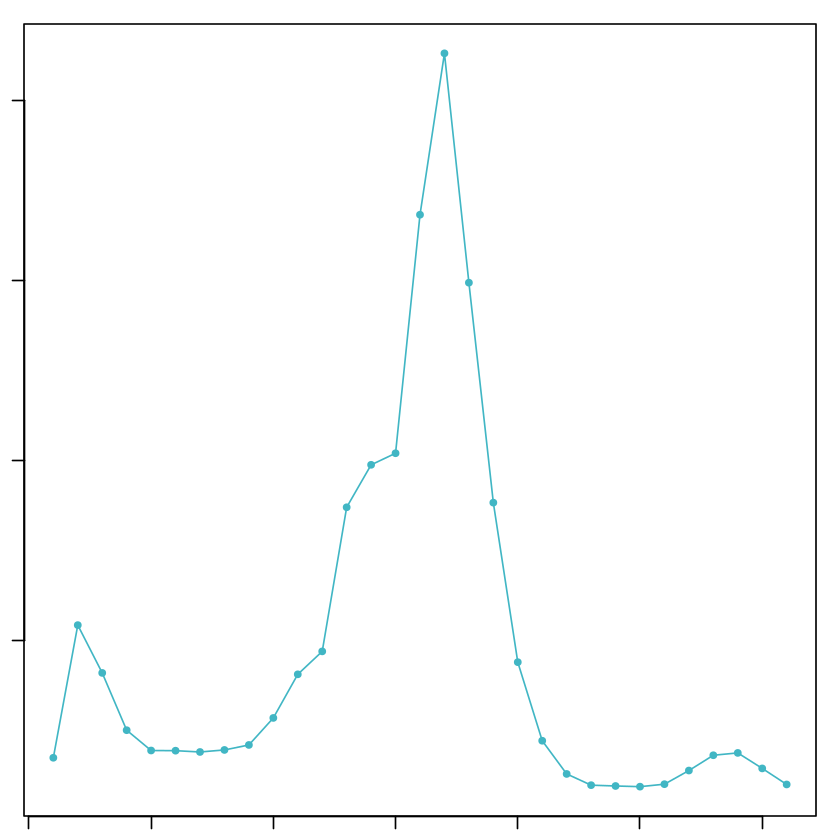

In [21]:
tryCatch({
    ## pK Identification (no ground-truth)
    set.seed(123)
    sweep.res.list <- paramSweep(srat, PCs=1:10, sct=FALSE)
    sweep.stats <- summarizeSweep(sweep.res.list, GT=FALSE)
    bcmvn <- find.pK(sweep.stats)
    ## Homotypic Doublet Proportion Estimate
    nExp_poi <- round(doublet_rate*nrow(srat@meta.data)) ## Assuming 7.5% doublet formation rate - tailor for your dataset
    # Run DoubletFinder with varying classification stringencies
    srat <- doubletFinder(srat, PCs = 1:10, pN = 0.25, pK = 0.09, nExp = nExp_poi, sct = FALSE)
    # Change the column names of doublet for metadata
    colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"pANN_")] <- "doublet_score"
    colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"DF.classifications_")] <- "doublet_class"
}, error = function(e) {
    print(e)
})               

[1] "Creating artificial doublets for pN = 5%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“at  -3.4389”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“radius  0.00034816”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“all data on boundary of neighborhood. make span bigger”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -3.4389”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.018659”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  1”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.031008”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“zero-width neighborhood. make span b

[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."
[1] "Creating artificial doublets for pN = 10%"
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


...

[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Defining neighborhoods..."
[1] "Computing pANN across all pK..."
[1] "pK = 0.005..."
[1] "pK = 0.01..."
[1] "pK = 0.02..."
[1] "pK = 0.03..."
[1] "pK = 0.04..."
[1] "pK = 0.05..."
[1] "pK = 0.06..."
[1] "pK = 0.07..."
[1] "pK = 0.08..."
[1] "pK = 0.09..."
[1] "pK = 0.1..."
[1] "pK = 0.11..."
[1] "pK = 0.12..."
[1] "pK = 0.13..."
[1] "pK = 0.14..."
[1] "pK = 0.15..."
[1] "pK = 0.16..."
[1] "pK = 0.17..."
[1] "pK = 0.18..."
[1] "pK = 0.19..."
[1] "pK = 0.2..."
[1] "pK = 0.21..."
[1] "pK = 0.22..."
[1] "pK = 0.23..."
[1] "pK = 0.24..."
[1] "pK = 0.25..."
[1] "pK = 0.26..."
[1] "pK = 0.27..."
[1] "pK = 0.28..."
[1] "pK = 0.29..."
[1] "pK = 0.3..."
NULL
[1] "Creating 833 artificial doublets..."
[1] "Creating Seurat object..."
[1] "Normalizing Seurat object..."
[1] "Finding variable genes..."


Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -3.542”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.19527”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.01561”


[1] "Scaling data..."


Centering and scaling data matrix



[1] "Running PCA..."
[1] "Calculating PC distance matrix..."
[1] "Computing pANN..."
[1] "Classifying doublets.."


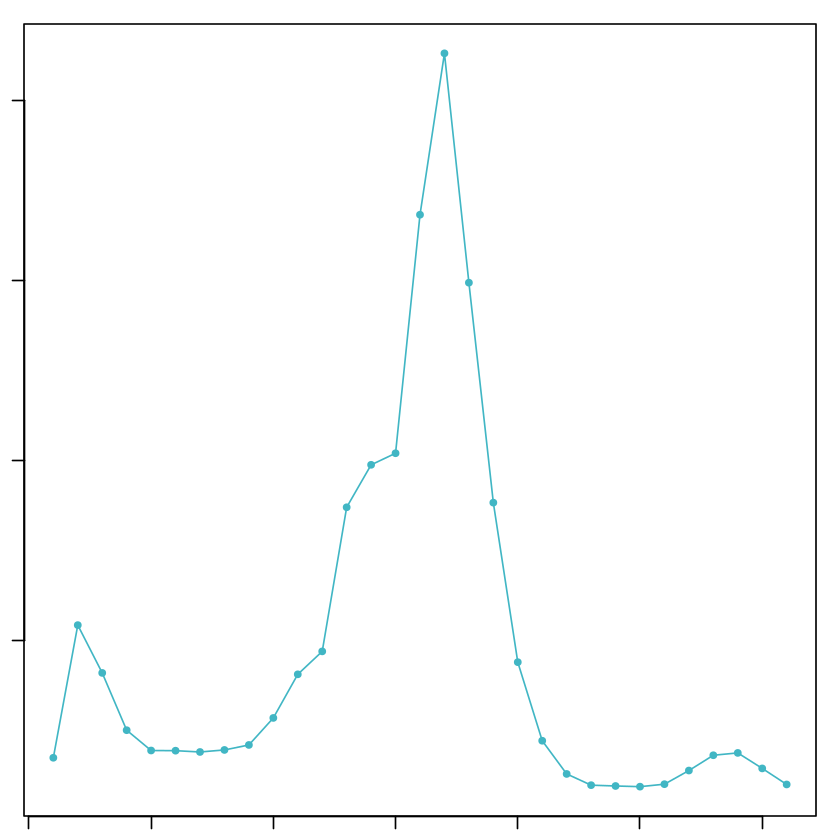

In [23]:
set.seed(123)
sweep.res.list <- paramSweep(srat, PCs=1:10, sct=FALSE)
sweep.stats <- summarizeSweep(sweep.res.list, GT=FALSE)
bcmvn <- find.pK(sweep.stats)
## Homotypic Doublet Proportion Estimate
nExp_poi <- round(doublet_rate*nrow(srat@meta.data)) ## Assuming 7.5% doublet formation rate - tailor for your dataset
# Run DoubletFinder with varying classification stringencies
srat <- doubletFinder(srat, PCs = 1:10, pN = 0.25, pK = 0.09, nExp = nExp_poi, sct = FALSE)
# Change the column names of doublet for metadata
# colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"pANN_")] <- "doublet_score"
# colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"DF.classifications_")] <- "doublet_class"

In [25]:
# Change the column names of doublet for metadata
colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"pANN_")] <- "doublet_score"
colnames(srat@meta.data)[str_starts(colnames(srat@meta.data),"DF.classifications_")] <- "doublet_class"

In [28]:
'doublet_class' %in% names(srat@meta.data)

[1] TRUE

In [27]:
names(srat@meta.data)

[1] "orig.ident"                   "nCount_RNA"                  
 [3] "nFeature_RNA"                 "channel"                     
 [5] "tissue"                       "subtissue"                   
 [7] "mouse.sex"                    "mouse.id"                    
 [9] "percent.ercc"                 "percent.ribo"                
[11] "free_annotation"              "cell_ontology_class"         
[13] "res.0.4"                      "previous_free_annotation"    
[15] "previous_cell_ontology_class" "cluster.ids"                 
[17] "cell_ontology_id"             "percent.mt"                  
[19] "percent.rb"                   "percent.hb"                  
[21] "percent.plat"                 "RNA_snn_res.0.5"             
[23] "seurat_clusters"              "doublet_score"               
[25] "doublet_class"

In [16]:
srat

An object of class Seurat 
2000 features across 2500 samples within 1 assay 
Active assay: RNA (2000 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, tsne

In [11]:
IsNormalized(srat[['RNA']]$counts)

[1] FALSE

In [26]:
srat[['RNA']]@meta.features

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable
,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Gstm1,162.3140,46952.042,18.33869,1276.8806,TRUE
Malat1,283.2628,29565.601,20.63057,828.0513,TRUE
S100a6,126.2724,21884.999,19.00820,691.2749,TRUE
Rpl41,145.0984,17471.618,18.53046,606.7235,TRUE
Ftl1,152.3312,14277.044,18.42526,540.4612,TRUE
Tmsb4x,108.4672,13588.059,19.81694,529.0631,TRUE
Rps29,118.4124,13162.180,19.31458,513.0639,TRUE
Rpl13,118.7936,11919.835,19.29801,509.9622,TRUE
Rpl37a,110.6196,13159.153,19.69610,507.5791,TRUE


In [1]:
srat@meta.data

ERROR: Error: object 'srat' not found


In [15]:
ncol(srat)

[1] 2500

In [5]:
# Return metadata and a list of assays if the default assay is not "RNA"
GetMetadataFromSeurat <- function(path, assay='RNA') {
    srat <- LoadSeurat(path)
    default_assay <- NULL
    assay_names <- NULL
    metadata <- NULL
    HVGsID <- NULL
    nGenes <- 0
    nCells <- 0
    genes <- NULL
    cells <- NULL
    pca <- NULL
    tsne <- NULL
    umap <- NULL
    info <- NULL
    # suffix <- tolower(GetSuffix(path))

    if(!is.null(srat)){
        assay_names <- names(srat@assays)
        if(assay != 'RNA' && assay %in% assay_names){
            DefaultAssay(srat) <- assay
        }
        else if(!(assay %in% assay_names)){
            assay <- DefaultAssay(srat)
        }
        default_assay <- DefaultAssay(srat)
        metadata <- srat@meta.data
        nCells <- ncol(srat)
        nGenes <- nrow(srat)
        genes <- rownames(srat)
        cells <- Cells(srat)
        HVGsID <- srat[[assay]]@var.features
        if('pca' %in% names(srat@reductions)) pca <- Embeddings(object = srat, reduction = "pca")
        if('tsne' %in% names(srat@reductions)) tsne <- Embeddings(object = srat, reduction = "tsne")
        if('umap' %in% names(srat@reductions)) umap <- Embeddings(object = srat, reduction = "umap")
        info <- print(srat)
    }
    srat <- NULL
    
    list(default_assay=default_assay, assay_names=assay_names, metadata=metadata, nCells=nCells, nGenes=nGenes, genes=genes, cells=cells, HVGsID=HVGsID, pca=pca, tsne=tsne, umap=umap, info=info)
}

In [6]:
results <- GetMetadataFromSeurat(path)
print(results$info)

Updating from v2.X to v3.X

Warning message:
“Not validating Assay objects”
Warning message:
“Not validating DimReduc objects”
Warning message:
“Not validating DimReduc objects”
Validating object structure

Updating object slots

Ensuring keys are in the proper structure

Updating matrix keys for DimReduc ‘pca’

Updating matrix keys for DimReduc ‘tsne’

Ensuring keys are in the proper structure

Ensuring feature names don't have underscores or pipes

Updating slots in RNA

Updating slots in pca

Updating slots in tsne

Setting tsne DimReduc to global

Validating object structure for Assay ‘RNA’

Validating object structure for DimReduc ‘pca’

Validating object structure for DimReduc ‘tsne’

Object representation is consistent with the most current Seurat version



An object of class Seurat 
23341 features across 2500 samples within 1 assay 
Active assay: RNA (23341 features, 0 variable features)
 2 layers present: counts, data
An object of class Seurat 
23341 features across 2500 samples within 1 assay 
Active assay: RNA (23341 features, 0 variable features)
 2 layers present: counts, data


In [7]:
print(results)

$default_assay
[1] "RNA"

$assay_names
[1] "RNA"

$metadata
                          orig.ident nCount_RNA nFeature_RNA  channel  tissue
10X_P4_3_AAAGTAGAGATGCCAG        10X      10291         2853 10X_P4_3 Bladder
10X_P4_3_AACCGCGTCCAACCAA        10X      17520         4194 10X_P4_3 Bladder
10X_P4_3_AACTCCCGTCGGGTCT        10X      12944         3347 10X_P4_3 Bladder
10X_P4_3_AACTCTTAGTTGCAGG        10X      19594         3851 10X_P4_3 Bladder
10X_P4_3_AACTCTTTCATAACCG        10X      14594         3809 10X_P4_3 Bladder
10X_P4_3_AAGACCTAGATCCGAG        10X      19190         3608 10X_P4_3 Bladder
10X_P4_3_AAGACCTAGGTGGGTT        10X      24484         4347 10X_P4_3 Bladder
10X_P4_3_AAGGAGCGTGCAACTT        10X       5005         1960 10X_P4_3 Bladder
10X_P4_3_AAGTCTGAGATAGTCA        10X       6253         2236 10X_P4_3 Bladder
10X_P4_3_ACAGCTATCATACGGT        10X      15910         3374 10X_P4_3 Bladder
10X_P4_3_ACATACGCAGCTCCGA        10X       2881         1558 10X_P4_3 Bladder
10X_

In [ ]:
assay_names <- names(srat_v3@assays)
'RNA' %in% assay_names

In [ ]:
length(assay_names)

In [ ]:
info = print(srat)

In [ ]:
info

In [ ]:
tools::file_path_sans_ext(path)

In [ ]:
# SaveH5Seurat(srat, filename = "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat", overwrite = TRUE, verbose = FALSE)
saveRDS(object = srat, file = "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.rds")

In [ ]:
robj <- readRDS("/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.rds")
robj

In [ ]:
srat <- LoadSeurat("//ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.rds")
# srat <- LoadSeurat("/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat")
srat

In [ ]:
SaveH5Seurat(srat, filename = "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat", overwrite = TRUE, verbose = FALSE)
srat <- LoadSeurat("/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat")
srat

In [ ]:
srat <- tryCatch(
        LoadSeurat(path),
        error = function(e) {
            stop("The file format is not supported.")
            print(e)
        }
    )

In [ ]:
srat

In [ ]:
UMAPPlot(object = srat, label=T)

In [ ]:
srat@meta.data

In [ ]:
colnames(srat[['RNA']])

In [ ]:
srat[['pca']]

In [ ]:
srat <- Seurat::ReadH5AD(path)
srat

In [ ]:
adata <- LoadAnndata(path)
adata

In [ ]:
# Add dimension reduction
  embed_names <- unlist(adata$obsm_keys())
  if (length(embed_names) > 0) {
    embeddings <- sapply(embed_names, function(x) as.matrix(adata$obsm[[x]]), simplify = FALSE, USE.NAMES = TRUE)
    names(embeddings) <- embed_names
      for (name in embed_names) {
        rownames(embeddings[[name]]) <- colnames(srat[['RNA']])
      }
  }

In [ ]:
embeddings

In [ ]:
length(adata$obsm[['X_tsne']])

In [ ]:
adata$obsm[['X_tsne']]

In [ ]:
adata$layers

In [ ]:
adata$layers <- NULL
adata

In [ ]:
'' %in% names(adata$layers)

In [ ]:
names(adata$layers)

In [ ]:
for (layer in names(adata$layers)){
    print(layer)
  }

In [ ]:
is.null(names(adata$layers))

In [ ]:
names(adata$layers) == 'aaa'

In [ ]:
'scale.data' %in% names(adata$layers)

In [ ]:
adata$layers['scale.data']

In [ ]:
srat <- LoadSeurat("/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat")
srat

In [ ]:
print(srat[['umap']])

In [ ]:
dims=1:10
srat <- FindVariableFeatures(srat, selection.method = "vst")
srat <- ScaleData(srat, features = rownames(srat))

# PCA
# srat <- RunPCA(srat, features = VariableFeatures(srat), ndims.print = 6:10, nfeatures.print = 10)
srat <- RunPCA(srat, features = VariableFeatures(srat))

srat <- FindNeighbors(srat, dims=dims)
srat <- FindClusters(srat, resolution = 0.5)
srat

# TSNE
srat <- RunTSNE(srat, dims=dims)
# UMAP
srat <- RunUMAP(srat, dims=dims)

umap <- Embeddings(object = srat, reduction = "umap")

In [ ]:
embed_names <- unlist(adata$obsm_keys())
embed_names

In [ ]:
adata$obsm[['X_umap']]

In [ ]:
adata$obsm[['X_pca']]

In [ ]:
as.matrix(adata$obsm[['X_pca']])

In [ ]:
adata_Seurat <- CreateSeuratObject(counts = t(adata$X), meta.data = adata$obs)
adata_Seurat

In [ ]:
adata_Seurat$data

In [ ]:
if (reticulate::py_to_r(sp$issparse(adata$X))) {
      X <- Matrix::t(reticulate::py_to_r(sp$csc_matrix(adata$X)))
    } else {
      X <- t(reticulate::py_to_r(adata$X))
    }

In [ ]:
adata$X

In [ ]:
.obs2metadata <- function(obs_pd, assay = "RNA") {
  obs_df <- .regularise_df(obs_pd, drop_single_values=FALSE, drop_na_values=TRUE)
  colnames(obs_df) <- sub("n_counts", paste0("nCounts_", assay), colnames(obs_df))
  colnames(obs_df) <- sub("n_genes", paste0("nFeaturess_", assay), colnames(obs_df))
  return(obs_df)
}

#' Prepare feature metadata
#'
#' This function prepare feature metadata from AnnData.var
#'
#' @param var_pd Input AnnData.var dataframe
#'
#' @return AnnData object
#'
#' @import reticulate
.var2feature_metadata <- function(var_pd) {
  var_df <- .regularise_df(var_pd, drop_single_values=FALSE, drop_na_values=TRUE)
  colnames(var_df) <- sub("dispersions_norm", "mvp.dispersion.scaled", colnames(var_df))
  colnames(var_df) <- sub("dispersions", "mvp.dispersion", colnames(var_df))
  colnames(var_df) <- sub("means", "mvp.mean", colnames(var_df))
  colnames(var_df) <- sub("highly_variable", "highly.variable", colnames(var_df))
  return(var_df)
}

In [ ]:
obs_df <- .obs2metadata(adata$obs)
var_df <- .var2feature_metadata(adata$var)
X <- t(adata$X)
colnames(X) <- rownames(obs_df)
rownames(X) <- rownames(var_df)
X

In [ ]:
rownames(obs_df)

In [ ]:
rownames(var_df)

In [ ]:
obs_df

In [ ]:
x_t <- Matrix::t(adata$X)
x_t

In [ ]:
adata_Seurat$RNA$counts

In [ ]:
adata_Seurat$RNA$counts

In [ ]:
Convert(path, "h5seurat", overwrite = TRUE)

In [ ]:
srat <- LoadH5Seurat(paste0(tools::file_path_sans_ext(path), ".h5seurat"), meta.data = FALSE, misc = FALSE)

In [ ]:
library(Seurat)
library(SingleCellExperiment)
library(SeuratDisk)
library(SeuratData)
input = "/ps/ai-ready/data/error/tung.rds"
robj <- readRDS(input)
robj

In [ ]:
logcounts(robj)

In [ ]:
'logcounts'  %in% names(robj)

In [ ]:
srat <- as.Seurat(robj, slot = "counts")

In [ ]:
# path <- "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.Robj"
path <- "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat"

In [ ]:
srat <- LoadSeurat(path)
srat

In [ ]:
adata <- SeuratToAnndata(srat)
adata

In [ ]:
adata$X

In [ ]:
obj <- srat
default_assay <- 'RNA'
if(paste0("nCount_", default_assay) %in% names(obj@meta.data)) names(obj@meta.data)[names(obj@meta.data) ==paste0("nCount_", default_assay)] <-"n_counts"
if(paste0("nFeature_", default_assay) %in% names(obj@meta.data)) names(obj@meta.data)[names(obj@meta.data) ==paste0("nFeature_", default_assay)] <-"n_genes"
if("percent.mt" %in% names(obj@meta.data)) names(obj@meta.data)[names(obj@meta.data) =="percent.mt"] <-"percent_mito"
obj@meta.data

In [ ]:
adata$layers['scale.data']

In [ ]:
srat[['RNA']]@counts

In [ ]:
mat <- Seurat::GetAssayData(object=srat, assay='RNA', layer='X')

In [ ]:
default_assay <- DefaultAssay(srat)
default_assay

In [ ]:
adata <- LoadAnndata("/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5ad")
adata

In [ ]:
adata$obsm['X_pca']

In [ ]:
Embeddings(object = srat, reduction = "pca")

In [ ]:
max(srat[['RNA']]@counts)

In [ ]:
min(srat[['RNA']]@counts)

In [ ]:
doublet_annnotation <- AnnotateDroplet(srat[[default_assay]]@counts)

In [ ]:
doublet_annnotation$doublet_score

In [ ]:
srat[["Doublet_score"]] <- doublet_annnotation$doublet_score
srat[["Doublet_class"]] <- doublet_annnotation$doublet_class

In [ ]:
data_mat = srat[['RNA']]@counts

In [ ]:
# -i data_mat -o doublet_score -o doublet_class

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

In [ ]:
srat[["Doublet_score"]] <- doublet_score

In [ ]:
srat[["Doublet_class"]] <- doublet_class

In [ ]:
srat[[]]

In [ ]:
dim(srat[['RNA']]@counts)
dim(srat)
dim(srat@meta.data)

In [ ]:
if(!paste0("nCount_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nCount_", default_assay)]] <- colSums(x = srat[[default_assay]], slot = "counts")  # nCount of the default assay
if(!paste0("nFeature_", default_assay) %in% names(x = srat[[]])) srat[[paste0("nFeature_", default_assay)]] <- colSums(x = GetAssayData(object = srat[[default_assay]], slot = "counts") > 0)  # nFeature of the default assay

In [ ]:
head(srat@meta.data)

In [ ]:
output_path <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat'
SaveH5Seurat(srat, filename = output_path, overwrite = TRUE, verbose = TRUE)

In [ ]:
srat1 <- LoadH5Seurat(output_path)
srat1

In [ ]:
srat1@meta.data

In [ ]:
adata_path <- Convert('/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat', dest = "h5ad" , overwrite = TRUE)
adata_path

In [ ]:
# Calculate the percentage of mitocondrial per cell and add to the metadata.
if(! "percent.mt" %in% names(x = srat[[]])) srat[["percent.mt"]] <- PercentageFeatureSet(srat, pattern = "^MT-")
# Calculate the proportion gene expression that comes from ribosomal proteins.
if(! "percent.rb" %in% names(x = srat[[]])) srat[["percent.rb"]] <- PercentageFeatureSet(srat, pattern = "^RP[SL]")

# Percentage hemoglobin genes - includes all genes starting with HB except HBP.
if(! "percent.hb" %in% names(x = srat[[]])) srat[["percent.hb"]] <- PercentageFeatureSet(srat, pattern = "^HB[^(P)]")
if(! "percent.plat" %in% names(x = srat[[]])) srat[["percent.plat"]] <- PercentageFeatureSet(srat, pattern = "PECAM1|PF4")
head(srat@meta.data)

In [ ]:
# Add the doublet annotation
doublets <- read.table(here::here('api/tools/qc/scrublet_calls.tsv'), header = F, row.names = 1)
colnames(doublets) <- c("Doublet_score", "Is_doublet")
srat <- AddMetaData(srat, doublets)
# srat[['Is_doublet']] <- !is.na(srat[['Is_doublet']])

In [ ]:
head(srat@meta.data)

In [ ]:
srat@meta.data

In [ ]:
names(srat@meta.data)[names(srat@meta.data) =="nCount_RNA"] <-"n_counts"
srat@meta.data

In [ ]:
names(srat@meta.data)

In [ ]:
nFeature_min=200
nFeature_max=0
percent_mt_max=5
percent_rb_min=0
srat <- subset(srat, subset = paste0("nFeature_", default_assay) > nFeature_min & percent.mt < percent_mt_max)
if(nFeature_max != 0) srat <- subset(srat, subset = paste0("nFeature_", default_assay) < nFeature_max)
if(percent_rb_min != 0)  srat <- subset(srat, subset = percent.rb > percent_rb_min)

In [ ]:
srat <- subset(srat, subset = Is_doublet != 'True' | is.na(Is_doublet))

In [ ]:
#' Regularise dataframe
#'
#' This function checks if certain columns of a dataframe is of a single value
#' and drop them if required
#'
#' @param df Input data frame, usually cell metadata table (data.frame-like
#'   object)
#' @param drop_single_values Drop columns with only a single value (logical)
#'
#' @return Dataframe
.regularise_df <- function(df, drop_single_values=FALSE, drop_na_values=TRUE) {
  if (ncol(df) == 0) df[["name"]] <- rownames(df)
  if (drop_single_values) {
    k_singular <- sapply(df, function(x) length(unique(x)) == 1)
    if (sum(k_singular) > 0) {
      warning(
        paste("Dropping single category variables:"),
        paste(colnames(df)[k_singular], collapse = ", ")
      )
    }
    df <- df[, !k_singular, drop = F]
    if (ncol(df) == 0) df[["name"]] <- rownames(df)
  }
 if (drop_na_values) {
    k_na <- sapply(srat@meta.data, function(x) sum(is.na(x))==length(x))
    if (sum(k_na) > 0) {
      warning(
        paste("Dropping NA category variables:"),
        paste(colnames(df)[k_na], collapse = ", ")
      )
    }
    df <- df[, !k_na, drop = F]
    if (ncol(df) == 0) df[["name"]] <- rownames(df)
  }
  return(df)
}

In [ ]:
output_path_rds <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.rds'
saveRDS(srat, output_path_rds)
srat1 <- LoadSeurat(output_path_rds)
srat1

In [ ]:
k_na <- sapply(srat@meta.data, function(x) sum(is.na(x))==length(x))
k_na
sum(k_na)

In [ ]:
srat_qc@meta.data %>% is.na()

In [ ]:
k_singular <- sapply(srat_qc@meta.data, function(x) length(unique(x)) == 1)
k_singular

In [ ]:
srat_qc@meta.data

In [ ]:
srat@meta.data <- .regularise_df(srat@meta.data, drop_single_values=FALSE, drop_na_values=TRUE)
srat@meta.data

In [ ]:
srat_qc@meta.data <- .regularise_df(srat_qc@meta.data, drop_single_values = FALSE)
srat_qc@meta.data

In [ ]:
output_path <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat'
SaveH5Seurat(srat_qc, filename = output_path, overwrite = TRUE, verbose = TRUE)
srat_3 <- LoadH5Seurat(output_path)
srat_3

In [ ]:
output_path <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat'
SaveH5Seurat(srat1, filename = output_path, overwrite = TRUE, verbose = TRUE)
srat_2 <- LoadH5Seurat(output_path)
srat_2

In [ ]:
srat1[["meta.data"]]

In [ ]:
srat1@meta.data

In [ ]:
devtools::install_github("cellgeni/sceasy")

In [ ]:
sceasy::convertFormat(srat1, from="seurat", to="anndata",
                       outFile='/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5ad')

In [ ]:
adata <- LoadAnndata('/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5ad')
adata

In [ ]:
adata$obs

In [ ]:
adata$X

In [ ]:
srat_qc <- CreateSeuratObject(counts=srat[['RNA']]@counts, meta.data=srat@meta.data, project = Project(srat))
srat_qc

In [ ]:
output_path <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat'
SaveH5Seurat(srat_qc, filename = output_path, overwrite = TRUE, verbose = TRUE)
srat_qc_1 <- LoadH5Seurat(output_path)
srat_qc_1

In [ ]:
output_path <- '/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5Seurat'
SaveH5Seurat(srat, filename = output_path, overwrite = TRUE, verbose = TRUE)
srat1 <- LoadH5Seurat(output_path)
srat1

In [ ]:
srat <- subset(srat, subset = Is_doublet != 'True')

In [ ]:
srat[["meta.data"]]

In [ ]:
Cells(srat)

In [ ]:
srat <- NormalizeData(srat, normalization.method = "LogNormalize", scale.factor = 10000)
srat <- FindVariableFeatures(srat, selection.method = "vst")
srat <- ScaleData(srat, features = rownames(srat))
srat
dim(srat)
dim(srat@meta.data)

In [ ]:
srat[['Doublet_score']][sapply(srat[['Doublet_score']], is.na)] <- 0
srat[['Doublet_score']]

In [ ]:
srat[['Doublet_score']] <- !is.na(srat[['Doublet_score']])


In [ ]:
# srat <- subset(srat, subset = percent.rb >= 0)
srat <- subset(srat, subset = is.na(Is_doublet))
srat

In [ ]:
srat[['Is_doublet']] <- !is.na(srat[['Is_doublet']])

In [ ]:
srat <- subset(srat, subset = Is_doublet != 'True')
srat

In [ ]:
srat@meta.data

In [ ]:
'nCount_RNA' %in% names(srat@meta.data)

In [ ]:
result <- GetMetadataFromSeurat(path)
result

In [ ]:
suffix <- tolower(get_suffix(path))
suffix

In [ ]:
seurat_object <- LoadSeurat(path)
seurat_object

In [ ]:
'umap' %in% names(seurat_object@reductions)

In [ ]:
genes <- rownames(seurat_object)
typeof(genes)
genes

In [ ]:
cells <- Cells(seurat_object)
typeof(cells)
cells

In [ ]:
pca <- Embeddings(object = seurat_object, reduction = "pca")
typeof(pca)
pca

In [ ]:
name <- load(path)
seurat_object <- UpdateSeuratObject(get(name))

In [ ]:
seurat_object

In [ ]:
features <- seurat_object[['RNA']]@var.features
typeof(features)
features

In [ ]:
#获取当前用的Idents
Idents(seurat_object)
levels(seurat_object)

In [ ]:
#总数目
nCells <- ncol(seurat_object)
nGenes <- nrow(seurat_object)

nCells
nGenes

In [ ]:
dim=1:10
class(dim)

In [ ]:
x <- 1:10
x

In [ ]:
class(x)

In [ ]:
devtools::install_github('JiekaiLab/dior')

In [ ]:
source("../tools/benchmarks/clustering/seurat.R")
path = "/ps/ai-ready/data/Clustering/Tabula_Muris/droplet_Bladder_seurat_tiss.h5ad"

In [ ]:
clustering <- function(path, labels, dims=1:10){ # labels: column name of labels in srat@meta.data
    srat <- tryCatch(
        LoadSeurat(path),
        error = function(e) {
            stop("The file format is not supported.")
            print(e)
        }
    )

    srat <- FindVariableFeatures(srat, selection.method = "vst")
    srat <- ScaleData(srat, features = rownames(srat))

    # PCA
    # srat <- RunPCA(srat, features = VariableFeatures(srat), ndims.print = 6:10, nfeatures.print = 10)
    srat <- RunPCA(srat, features = VariableFeatures(srat))

    srat <- FindNeighbors(srat, dims=dims)
    srat <- FindClusters(srat, resolution = 0.5)
    srat

    # TSNE
    srat <- RunTSNE(srat, dims=dims)
    # UMAP
    srat <- RunUMAP(srat, dims=dims)

    umap <- Embeddings(object = srat, reduction = "umap")

    list(labels=as.list(srat@meta.data[labels]), labels_pred=as.list(srat@meta.data["seurat_clusters"]), umap=umap)
}

In [ ]:
result <- clustering(path, 'cluster.ids')
result

In [ ]:
result